## 02. Eksploratorna analiza podataka (EDA)

### Uvoz biblioteka

In [2]:
import os
import ast
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from itertools import combinations
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Biblioteke su uspjesno ucitane!")

Biblioteke su uspjesno ucitane!


### Učitavanje pripremljenih podataka

In [3]:
PROCESSED_DIR = Path("../data/processed")

dataset = pd.read_csv(PROCESSED_DIR / "dataset_final.csv")

dataset['label'] = dataset['label'].apply(ast.literal_eval)
dataset['seq_length'] = dataset['Sequence'].str.len()

CLASS_COLUMNS = ['Hydrolase', 'Receptor', 'Structural protein',
                  'Transcription factor', 'Transport protein']

print(f"Ukupno proteina: {len(dataset)}")
print(f"Single-Class: {(~dataset['is_multilabel']).sum()}")
print(f"Multi-Class:  {dataset['is_multilabel'].sum()}")

Ukupno proteina: 7043
Single-Class: 6663
Multi-Class:  380


In [21]:
dataset.head()

,Sequence,Entry,label,num_classes,is_multilabel,Hydrolase,Receptor,Structural protein,Transcription factor,Transport protein,seq_length
0,DKQLDADVSPKPTIFLPSIAETKLQKAGTYLCLLEKFFPDIIKIHW...,P03986,[Receptor],1,False,0,1,0,0,0,189
1,MAAAAAAAAAVGVRLRDCCSRGAVLLLFFSLSPRPPAAAAWLLGLR...,Q9NRU3,[Transport protein],1,False,0,0,0,0,1,951
2,MAAAAAALSGAGTPPAGGGAGGGGAGGGGSPPGGWAVARLEGREFE...,Q01167,[Transcription factor],1,False,0,0,0,1,0,660
3,MAAAAAEEGMEPRALQYEQTLMYGRYTQDLGAFAKEEAARIRLGGP...,P51788,[Transport protein],1,False,0,0,0,0,1,898
4,MAAAAALRAPAQSSVTFEDVAVNFSLEEWSLLNEAQRCLYRDVMLE...,Q9NXT0,[Transcription factor],1,False,0,0,0,1,0,402


## Dio A - Opšta EDA nad cijelim skupom

### Distribucija klasa 

In [22]:
# Paleta boja
set2_colors = sns.color_palette("Set2", len(CLASS_COLUMNS))
palette = dict(zip(CLASS_COLUMNS, set2_colors))

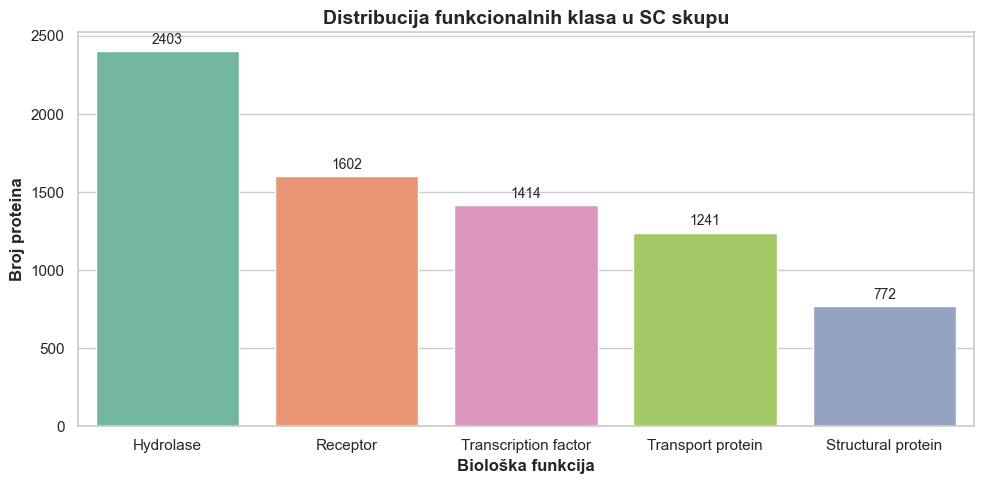

In [23]:
class_counts = dataset[CLASS_COLUMNS].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values,  hue=class_counts.index, palette=palette, legend=False)
plt.title("Distribucija funkcionalnih klasa u SC skupu", fontsize=14, fontweight="bold")
plt.xlabel("Biološka funkcija", fontweight='bold')
plt.ylabel("Broj proteina", fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')
    
plt.tight_layout()
plt.savefig("../results/fig1_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza dužina sekvenci po klasama 

In [24]:
dataset['seq_length'] = dataset['Sequence'].apply(len)

long_format = []
for cls in CLASS_COLUMNS:
    subset = dataset.loc[dataset[cls] == 1, ['seq_length']].copy()
    subset['label'] = cls
    long_format.append(subset)
long_df = pd.concat(long_format, ignore_index=True)

print("Statistika duzine sekvenci po klasama (broj aminokiselina):")
long_df.groupby('label')['seq_length'].describe().round(1)


Statistika duzine sekvenci po klasama (broj aminokiselina):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Hydrolase,2403.0,637.5,502.8,51.0,315.0,498.0,804.5,6306.0
Receptor,1602.0,542.8,469.3,85.0,314.0,365.0,577.5,6306.0
Structural protein,772.0,797.4,1602.7,25.0,182.8,417.0,810.0,34350.0
Transcription factor,1414.0,542.2,332.5,34.0,354.0,481.5,628.8,3953.0
Transport protein,1241.0,632.2,553.5,51.0,323.0,501.0,735.0,5058.0


#### Histogram

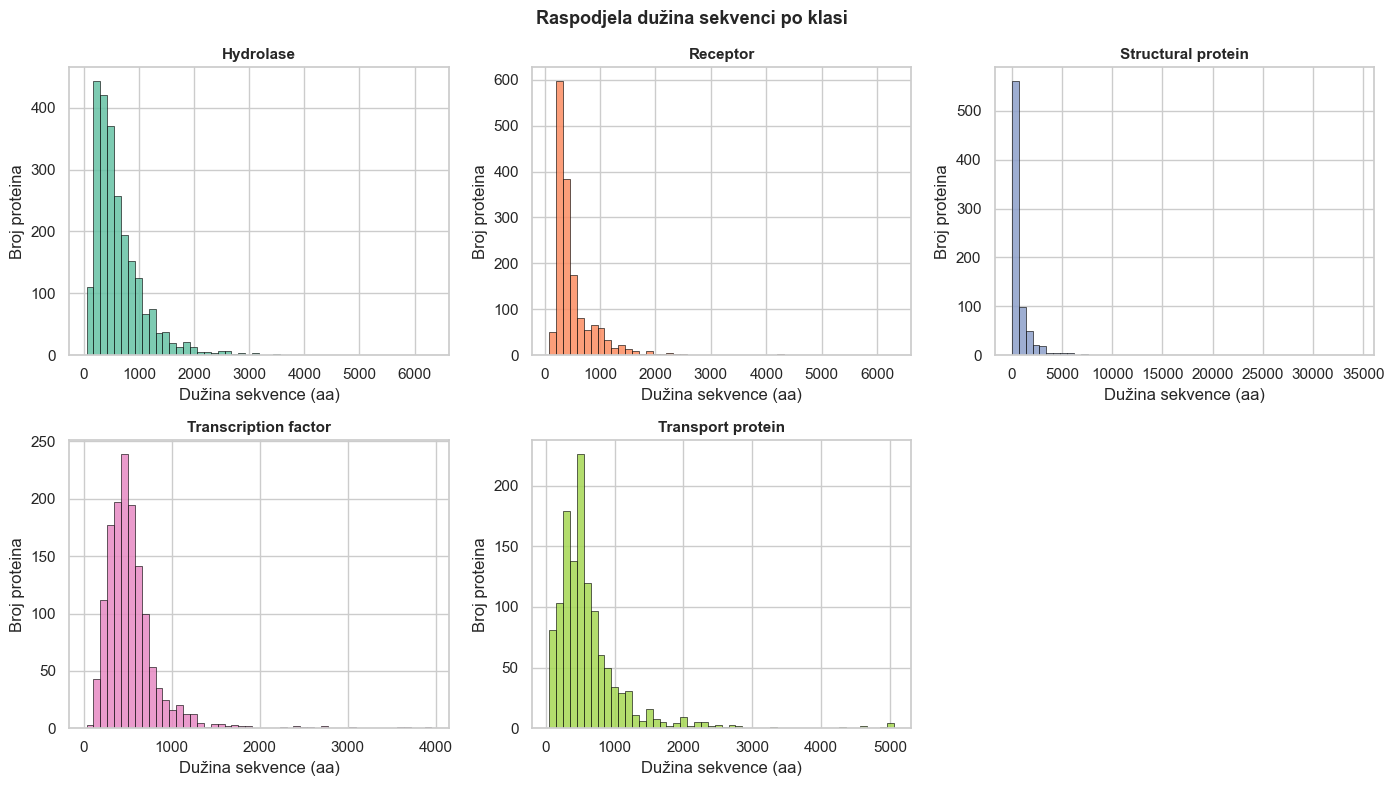

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_COLUMNS):
    subset = long_df[long_df['label'] == cls]['seq_length']
    
    # Crtanje histograma 
    axes[i].hist(subset, bins=50, color=palette[cls], alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[i].set_title(cls, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Dužina sekvence (aa)")
    axes[i].set_ylabel("Broj proteina")

axes[5].set_visible(False)
plt.suptitle("Raspodjela dužina sekvenci po klasi", fontsize=13, fontweight="bold")
plt.tight_layout()

plt.savefig("../results/fig2_length_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

#### Boxplot

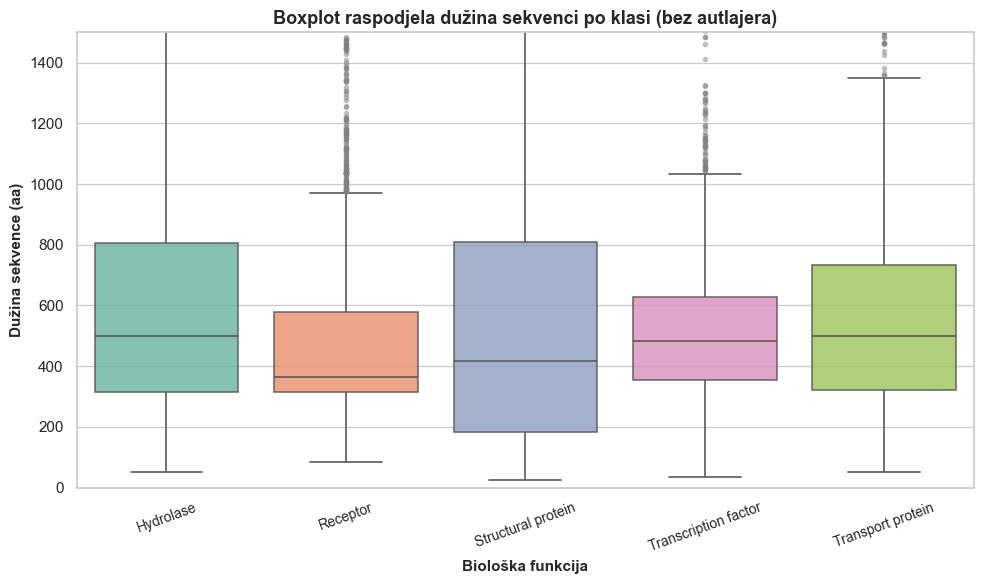

In [26]:
plt.figure(figsize=(10, 6))

# Stil za prikaz autlajera 
flierprops = dict(
    marker = 'o',
    markersize = 4,
    markerfacecolor = 'gray',
    markeredgecolor = 'none',
    alpha = 0.5
)

ax = sns.boxplot(
    data=long_df,
    x='label',
    y='seq_length',
    hue='label',            
    legend=False,
    palette=palette,
    showfliers=True,  
    flierprops = flierprops,
    boxprops=dict(alpha=0.85),
    linewidth=1.2
)

plt.ylim(0, 1500)
plt.title("Boxplot raspodjela dužina sekvenci po klasi (bez autlajera)", fontsize=13, fontweight='bold')
plt.xlabel("Biološka funkcija", fontsize=11, fontweight='bold')
plt.ylabel("Dužina sekvence (aa)", fontsize=11, fontweight='bold')
plt.xticks(rotation=20, fontsize=10)

plt.tight_layout()
plt.savefig("../results/fig3_length_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza AAC sastava po klasi

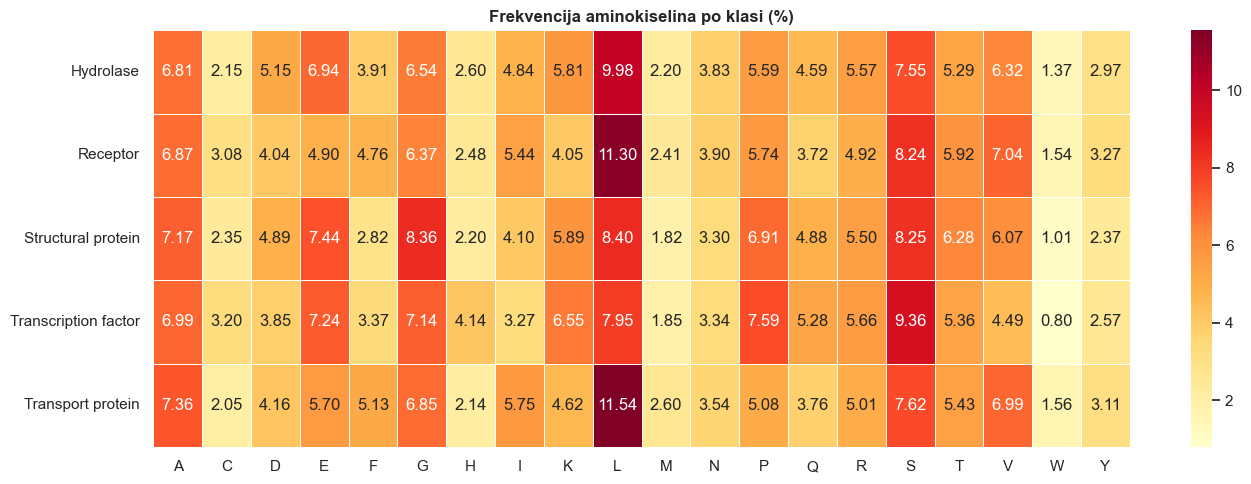

In [27]:
aminoacids = list("ACDEFGHIKLMNPQRSTVWY")

freq_matrix = {}
for cls in CLASS_COLUMNS:
    all_seqs = "".join(dataset.loc[dataset[cls] == 1, 'Sequence'].values)
    total = len(all_seqs)
    freq_matrix[cls] = {aa: round(all_seqs.count(aa) / total * 100, 2) for aa in aminoacids}
freq_df = pd.DataFrame(freq_matrix).T

plt.figure(figsize=(14, 5))
sns.heatmap(freq_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Frekvencija aminokiselina po klasi (%)", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/fig3_aac_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza n-grama po klasi

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer


# Definisanje parametara
ngram_range = (2, 4)
top_n = 20

vectorizer = TfidfVectorizer(
    analyzer='char', ngram_range=ngram_range, max_df=10000, lowercase=False
)
vectorizer.fit(dataset['Sequence'])

# Izračunavanje prosječnog TF-IDF score-a po klasi
feature_names = vectorizer.get_feature_names_out()
tfidf_per_class = pd.DataFrame(
    index=CLASS_COLUMNS, columns=feature_names, dtype=float
)

for cls in CLASS_COLUMNS:
    class_sequences = dataset[dataset[cls] == 1]['Sequence']
    tfidf_matrix = vectorizer.transform(class_sequences)
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    tfidf_per_class.loc[cls] = mean_tfidf

# Računanje varijanse za svaki n-gram kroz sve klase
ngram_variance = tfidf_per_class.var(axis=0)
# Rangiranje n-grama prema najvećoj varijansi
top_ngrams = ngram_variance.nlargest(top_n).index

heatmap_data = tfidf_per_class[top_ngrams]

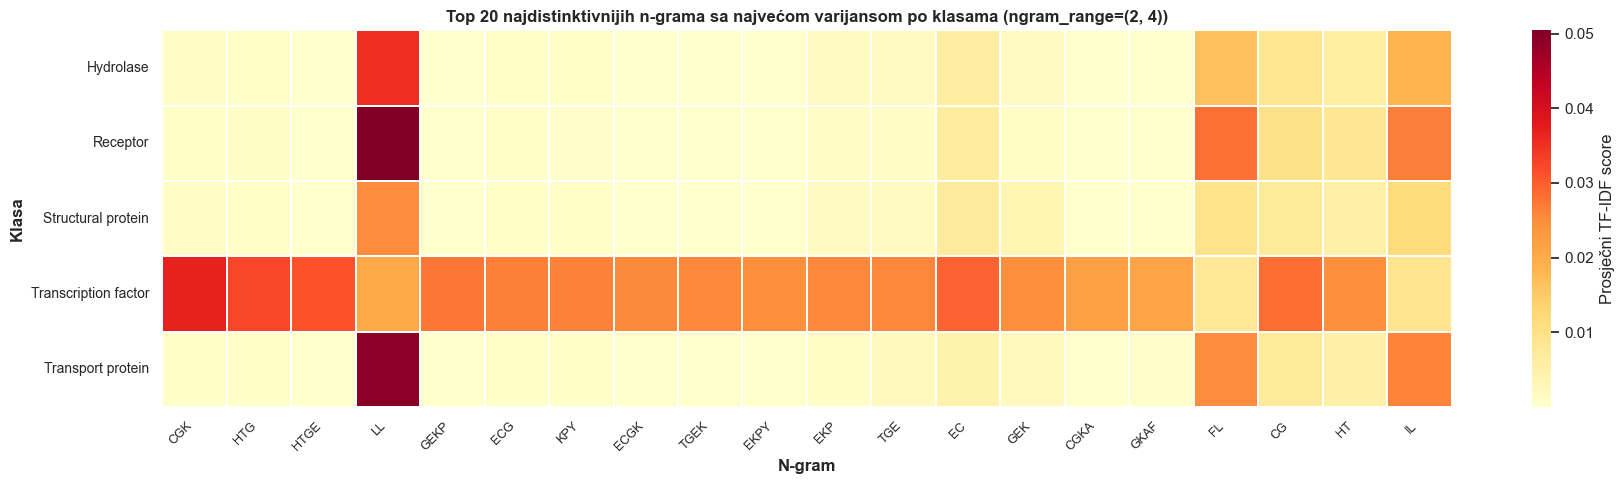

In [78]:
plt.figure(figsize=(18, 5))

sns.heatmap(
    heatmap_data.astype(float),
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Prosječni TF-IDF score'}
)

plt.title(
    f'Top {top_n} najdistinktivnijih n-grama sa najvećom varijansom po klasama '
    f'(ngram_range={ngram_range})',
    fontweight="bold"
)
plt.xlabel('N-gram', fontweight="bold")
plt.ylabel('Klasa', fontweight="bold")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
#plt.savefig('results/fig5_ngram_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Fizičko-hemijske osobine po klasi

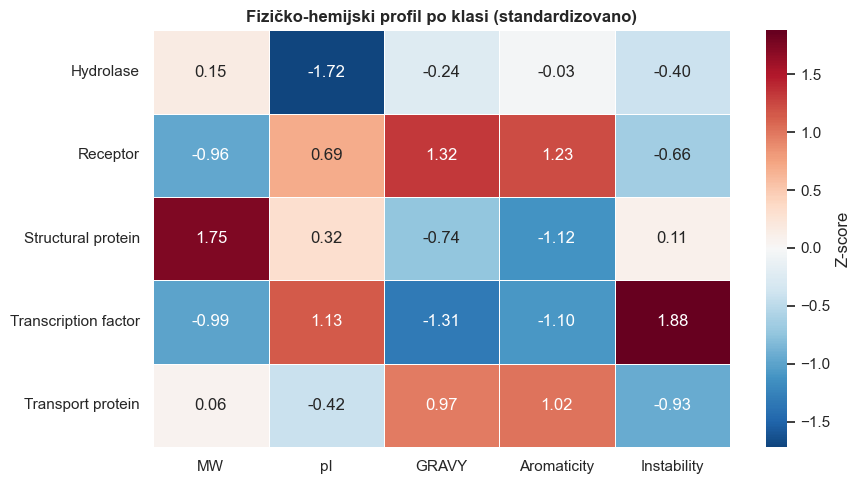

In [9]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import StandardScaler

def extract_physicochemical(sequence):
    a = ProteinAnalysis(sequence)
    return {
        'MW': a.molecular_weight(), 'pI': a.isoelectric_point(),
        'GRAVY': a.gravy(), 'Aromaticity': a.aromaticity(),
        'Instability': a.instability_index()
    }

ph_features = dataset['Sequence'].apply(lambda x: pd.Series(extract_physicochemical(x)))
ph_features.index = dataset["Entry"]
ph_features.to_csv("../data/processed/physicochemical_features.csv")

heatmap_rows = []
for cls in CLASS_COLUMNS:
    mask = dataset.loc[dataset[cls] == 1, "Entry"]
    heatmap_rows.append(ph_features.loc[mask].mean().rename(cls))
heatmap_data_ph = pd.DataFrame(heatmap_rows)

scaler = StandardScaler()
heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data_ph),
    index=heatmap_data_ph.index, columns=heatmap_data_ph.columns
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_scaled, cmap='RdBu_r', annot=True, fmt=".2f",
            linewidths=0.5, center=0, cbar_kws={'label': 'Z-score'})
plt.title("Fizičko-hemijski profil po klasi (standardizovano)", fontweight="bold")
#plt.savefig("../results/fig4_physicochemical_heatmap.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Single-Class vs. Multi-Class proteini

Graf prikazuje da li se multifunkcionalni proteini razlikuju po dužini sekvence od proteina sa jednom funkcijom. 

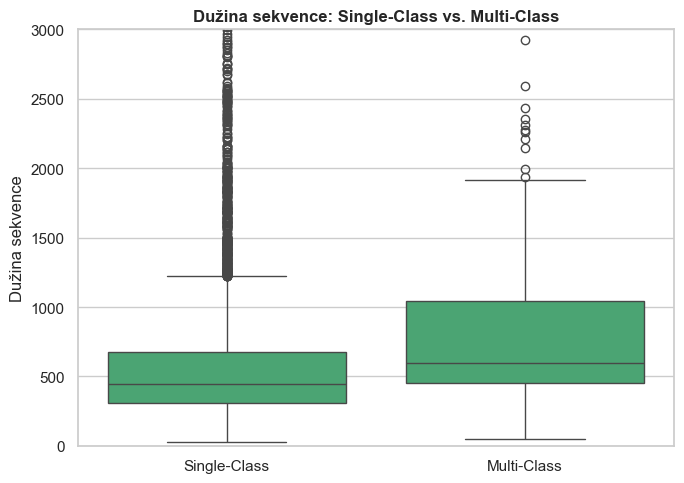

In [54]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='is_multilabel', y='seq_length', data=dataset, color="mediumseagreen")
plt.xticks([0, 1], ['Single-Class', 'Multi-Class'])
plt.title("Dužina sekvence: Single-Class vs. Multi-Class", fontweight="bold")
plt.xlabel("")
plt.ylabel("Dužina sekvence")
plt.ylim(0, 3000)
plt.tight_layout()
#plt.savefig("../results/fig5_length_sc_vs_mc.png", dpi=300, bbox_inches="tight")
plt.show()

## Dio B - EDA za SC eksperiment

Izdvajamo proteine sa tačno jednom funkcionalnom klasom i provjeravamo da li se raspodjela klasa razlikuje od raspodjele klasa u cijelom skupu.

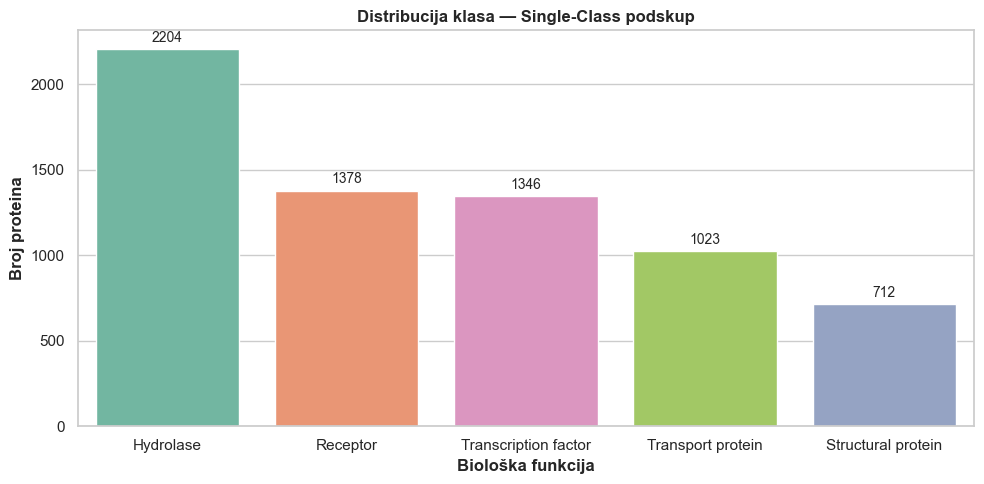

In [30]:
sc_dataset = dataset[~dataset['is_multilabel']].copy()
sc_dataset['label'] = sc_dataset['label'].apply(lambda x: x[0])

sc_counts = sc_dataset['label'].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=sc_counts.index, y=sc_counts.values,  hue=sc_counts.index, palette=palette, legend=False)
plt.title("Distribucija klasa — Single-Class podskup", fontweight="bold")
plt.xlabel("Biološka funkcija", fontweight='bold')
plt.ylabel("Broj proteina", fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
#plt.savefig("../results/fig6_sc_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Dio C - EDA za MC eksperiment

### Analiza broja klasa po proteinu (Label Cardinality)

Label cardinality: 1.055
Label density: 0.211


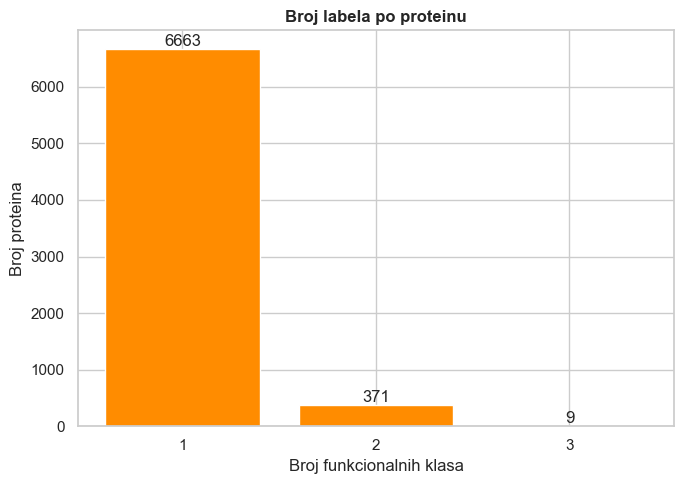

In [40]:
num_labels = len(CLASS_COLUMNS)
cardinality = dataset['num_classes'].mean()
density = cardinality / num_labels
print(f"Label cardinality: {cardinality:.3f}")
print(f"Label density: {density:.3f}")

counts = dataset['num_classes'].value_counts().sort_index()
plt.figure(figsize=(7, 5))
plt.bar(counts.index.astype(str), counts.values, color="darkorange")
plt.title("Broj labela po proteinu", fontweight="bold")
plt.xlabel("Broj funkcionalnih klasa")
plt.ylabel("Broj proteina")
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
#plt.savefig("../results/fig7_label_cardinality.png", dpi=300, bbox_inches="tight")
plt.show()

### Matrica ko-pojavljivanja klasa (Co-occurence)

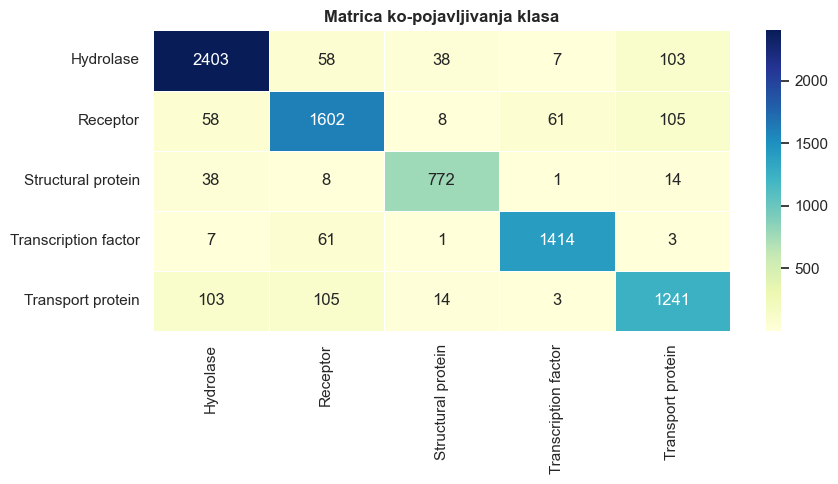

In [45]:
label_counts = dataset[CLASS_COLUMNS].sum()
mc_subset = dataset[dataset['is_multilabel']]

cooc = pd.DataFrame(0, index=CLASS_COLUMNS, columns=CLASS_COLUMNS)
for labels in mc_subset['label']:
    for c1, c2 in combinations(labels, 2):
        cooc.loc[c1, c2] += 1
        cooc.loc[c2, c1] += 1
for c in CLASS_COLUMNS:
    cooc.loc[c, c] = label_counts[c]

plt.figure(figsize=(9, 5))
sns.heatmap(cooc, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Matrica ko-pojavljivanja klasa", fontweight="bold")
plt.tight_layout()
#plt.savefig("../results/fig9_cooccurrence_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Najčešće kombinacije klasa

In [50]:
combination_counts = (
    mc_subset['label']
    .apply(lambda x: " + ".join(x))
    .value_counts()
    .reset_index()
)
combination_counts.columns = ['Kombinacija klasa', 'Broj proteina']
combination_counts['Udio u MC skupu (%)'] = (
    combination_counts['Broj proteina'] / len(mc_subset) * 100
).round(2)

print(f"Ukupan broj distinktnih kombinacija klasa: {len(combination_counts)}")
combination_counts

Ukupan broj distinktnih kombinacija klasa: 15


,Kombinacija klasa,Broj proteina,Udio u MC skupu (%)
0,Receptor + Transport protein,99,26.05
1,Hydrolase + Transport protein,98,25.79
2,Receptor + Transcription factor,58,15.26
3,Hydrolase + Receptor,52,13.68
4,Hydrolase + Structural protein,38,10.00
5,Structural protein + Transport protein,13,3.42
6,Receptor + Structural protein,7,1.84
7,Hydrolase + Transcription factor,4,1.05
8,Hydrolase + Receptor + Transport protein,4,1.05
9,Hydrolase + Receptor + Transcription factor,2,0.53


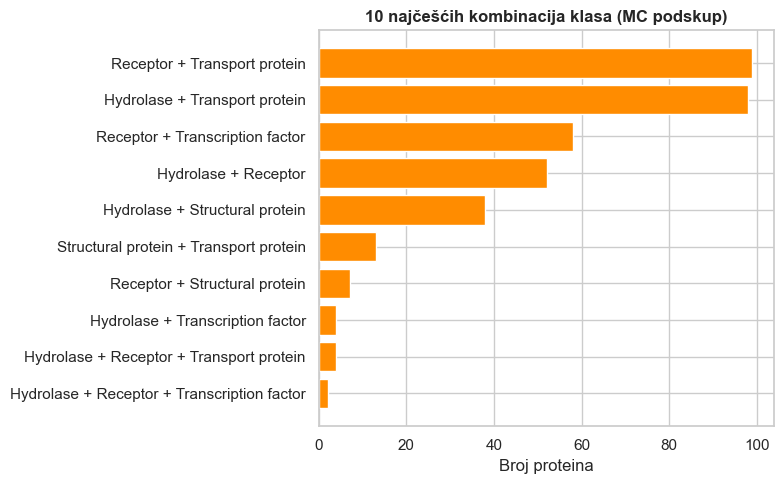

In [55]:
top_n = combination_counts.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_n['Kombinacija klasa'][::-1], top_n['Broj proteina'][::-1], color="darkorange")
plt.title("10 najčešćih kombinacija klasa (MC podskup)", fontweight="bold")
plt.xlabel("Broj proteina")
plt.tight_layout()
#plt.savefig("../results/fig9b_top_combinations.png", dpi=300, bbox_inches="tight")
plt.show()